In [1]:
import sys
import introns
import importlib
import warnings
import pickle

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from Bio import SeqIO
from Bio.SeqUtils import GC
from termcolor import colored
from sklearn.utils import class_weight
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, precision_recall_fscore_support, multilabel_confusion_matrix

importlib.reload(introns)

C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator _BinaryGaussianProcessClassifierLaplace from version 1.0.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator GaussianProcessClassifier from version 1.0.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn

<module 'introns' from 'c:\\Users\\annaw\\Studia\\eugleny\\ml_solutions_2\\ml_solutions_2\\introns.py'>

In [2]:
teal_color = "#599191"

## Trenowanie
4 klasy: konw, niekonw, inne pozycje, losowe sekwencje

In [3]:
### sprawdzanie ze introny nie sa swoimi wlasnymi wariantami

seqs = [i for i in SeqIO.parse("introns_for_4-class_classifier_training.fasta", 'fasta')]
for id1 in range(len(seqs)-1):
    s1 = seqs[id1]
    for id2 in range(id1+1, len(seqs)):
        s2 = seqs[id2]
        if s1.seq==s2.seq:
            print(s1.description)
            print(s2.description)
            print('\n')

In [4]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("introns_for_4-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else (2 if t=="intron_other" else 3))
    else:
        prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        its_characteristics = introns.compute_intron_characteristics(l)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, introns_classes, test_size=0.3, random_state=420)
introns_classes = np.array(introns_classes).reshape(-1,1)
classes_weights_4head = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

2683 2683 2683


In [1]:
#sprawdzanie korelacji miedzy cechami
pd.DataFrame(introns_characteristics).corr()

NameError: name 'plt' is not defined

In [11]:
#clf_4head = xgb.XGBClassifier(use_label_encoder=False, eval_metric='aucpr', objective='multi:softmax')
clf_4head = xgb.XGBClassifier(use_label_encoder=False,
                              eval_metric=balanced_accuracy_score,
                              objective='multi:softmax',
                              seed=123)
clf_4head.fit(X_train, y_train, sample_weight=classes_weights_4head);

pred_4head = clf_4head.predict(X_test)

In [12]:
print("4-class classifier accuracy score:", balanced_accuracy_score(y_test,pred_4head))

precision, recall, fscore, _ = precision_recall_fscore_support(y_test,pred_4head)
print("Precision:\t", precision)
print("recall:\t\t", recall)
print("f-score:\t", fscore)
print(multilabel_confusion_matrix(y_test,pred_4head))



4-class classifier accuracy score: 0.3723399463454968
Precision:	 [0.16666667 0.38888889 0.66896552 0.12698413]
recall:		 [0.65384615 0.34751773 0.1916996  0.2962963 ]
f-score:	 [0.265625   0.3670412  0.29800307 0.17777778]
[[[361 340]
  [ 36  68]]

 [[587  77]
  [ 92  49]]

 [[251  48]
  [409  97]]

 [[641 110]
  [ 38  16]]]


In [13]:
pickle.dump(clf_4head, open('4head_classifier.model', 'wb'))

## Trenowanie
3 klasy: konw, niekonw, inne pozycje

In [7]:
### sprawdzanie ze introny nie sa swoimi wlasnymi wariantami

seqs = [i for i in SeqIO.parse("introns_for_3-class_classifier_training.fasta", 'fasta')]
for id1 in range(len(seqs)-1):
    s1 = seqs[id1]
    for id2 in range(id1+1, len(seqs)):
        s2 = seqs[id2]
        if s1.seq==s2.seq:
            print(s1.description)
            print(s2.description)
            print('\n')

In [8]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("introns_for_3-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else 2)
    else:
        prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        its_characteristics = introns.compute_intron_characteristics(l)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

introns_classes = np.array(introns_classes).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, introns_classes, test_size=0.3, random_state=420)
classes_weights_3head = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

2483 2483 2483


In [9]:
#sprawdzanie korelacji miedzy cechami
pd.DataFrame(introns_characteristics).corr()

,0,1,2,3,4,5,6,7
0,1.000000,-0.031058,0.030244,0.000026,0.020030,NaN,0.015729,-0.009266
1,-0.031058,1.000000,0.027713,0.028255,0.040419,NaN,0.013974,0.000067
2,0.030244,0.027713,1.000000,-0.024415,0.359755,NaN,0.058210,-0.010302
3,0.000026,0.028255,-0.024415,1.000000,0.029951,NaN,0.036048,0.013205
4,0.020030,0.040419,0.359755,0.029951,1.000000,NaN,0.044315,-0.009948
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.015729,0.013974,0.058210,0.036048,0.044315,NaN,1.000000,0.023226
7,-0.009266,0.000067,-0.010302,0.013205,-0.009948,NaN,0.023226,1.000000


In [16]:
#clf_3head = MultiOutputClassifier(xgb.XGBClassifier(use_label_encoder=False, eval_metric='aucpr', objective='multi:softmax'))
clf_3head = MultiOutputClassifier(xgb.XGBClassifier(use_label_encoder=False,
                                                    eval_metric=balanced_accuracy_score,
                                                    objective='multi:softmax',
                                                    seed=123))
clf_3head.fit(X_train, y_train, sample_weight=classes_weights_3head);

pred_3head = clf_3head.predict(X_test)

In [17]:
print("3-class classifier accuracy score:", balanced_accuracy_score(y_test,pred_3head))

precision, recall, fscore, _ = precision_recall_fscore_support(y_test,pred_3head)
print("Precision:\t", precision)
print("recall:\t\t", recall)
print("f-score:\t", fscore)
print(multilabel_confusion_matrix(y_test,pred_3head))

3-class classifier accuracy score: 0.45002919576597084
Precision:	 [0.18506494 0.34579439 0.69955157]
recall:		 [0.53773585 0.49333333 0.3190184 ]
f-score:	 [0.27536232 0.40659341 0.43820225]
[[[388 251]
  [ 49  57]]

 [[455 140]
  [ 76  74]]

 [[189  67]
  [333 156]]]


In [18]:
pickle.dump(clf_3head, open('3head_classifier.model', 'wb'))

## Trenowanie
4 klasy: konw, niekonw, intermediate, losowe sekwencje

## Trenowanie - multiklasy

In [19]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("introns_for_3-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else 2)
    else:
        prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        its_characteristics = introns.compute_intron_characteristics(prev_exon_seq+intron_seq+next_exon_seq)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

introns_classes_multi = []
for i in introns_classes:
    is_k = True if i==0 else False
    is_nk = True if i==1 else False
    introns_classes_multi.append([is_k, is_nk])
    
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(introns_characteristics, introns_classes_multi, test_size=0.3, random_state=420)
classes_weights_multi = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

2483 2483 2483


In [20]:
#clf_multi = MultiOutputClassifier(xgb.XGBClassifier(eval_metric='aucpr'))
clf_multi = MultiOutputClassifier(xgb.XGBClassifier(eval_metric=balanced_accuracy_score, seed=123))
clf_multi.fit(X_train_multi, y_train_multi, sample_weight=classes_weights_multi);

In [21]:
pred_multi = clf_multi.predict(X_test_multi)


#print("Multiclass classifier accuracy score:", balanced_accuracy_score(y_test_multi,pred_multi))

precision, recall, fscore, _ = precision_recall_fscore_support(y_test_multi,pred_multi)
print("Precision:\t", precision)
print("recall:\t\t", recall)
print("f-score:\t", fscore)
print(multilabel_confusion_matrix(y_test_multi,pred_multi))

Precision:	 [0.16666667 0.39837398]
recall:		 [0.25471698 0.32666667]
f-score:	 [0.20149254 0.35897436]
[[[504 135]
  [ 79  27]]

 [[521  74]
  [101  49]]]


In [22]:
pickle.dump(clf_multi, open('multi_classifier.model', 'wb'))

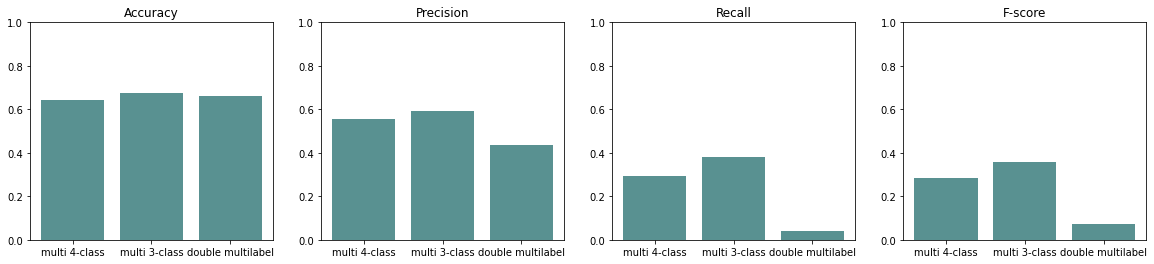

In [23]:
classifiers = ['multi 4-class', 'multi 3-class', 'double multilabel']
accuracies = [0.6422360248447205, 0.6738255033557047, 0.661744966442953]
precisions = [[0.44444444, 0.46341463, 0.65425532, 0.66666667],
              [0.5, 0.59259259, 0.67937853],
              [0.42857143, 0.44444444]]
recalls = [[0.03846154, 0.13475177, 0.97233202, 0.03703704],
           [0.04716981, 0.10666667, 0.98364008],
           [0.02830189, 0.05333333]]
fscores = [[0.07079646, 0.20879121, 0.78219396, 0.07017544],
           [0.0862069, 0.18079096, 0.80367586],
           [0.05309735, 0.0952381 ]]
fig, ax = plt.subplots(1,4,figsize=(20,4))
ax = ax.flatten()

#for classifier, a in zip(classifiers,accuracies):
ax[0].bar(classifiers, accuracies, color=teal_color)
ax[0].set_title('Accuracy')
ax[0].set_ylim((0,1))

ax[1].bar(classifiers, [np.mean(l) for l in precisions], color=teal_color)
ax[1].set_title('Precision')
ax[1].set_ylim((0,1))

ax[2].bar(classifiers, [np.mean(l) for l in recalls], color=teal_color)
ax[2].set_title('Recall')
ax[2].set_ylim((0,1))

ax[3].bar(classifiers, [np.mean(l) for l in fscores], color=teal_color)
ax[3].set_title('F-score')
ax[3].set_ylim((0,1))

plt.savefig('3_classifiers_scores.png')

## Stats w/ classifiers

In [24]:
clf_3head = pickle.load(open('3head_classifier.model', 'rb'))
#clf_4head = pickle.load(open('4head_classifier.model', 'rb'))
#clf_multi = pickle.load(open('multi_classifier.model', 'rb'))